# Load

In [1]:
import pandas as pd

In [32]:
df = pd.read_csv('../Data/cs-training.csv')

In [8]:
df

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
149995,149996,0,0.040674,74,0,0.225131,2100.0,4,0,1,0,0.0
149996,149997,0,0.299745,44,0,0.716562,5584.0,4,0,1,0,2.0
149997,149998,0,0.246044,58,0,3870.000000,NaN,18,0,1,0,0.0
149998,149999,0,0.000000,30,0,0.000000,5716.0,4,0,0,0,0.0


In [16]:
df.describe()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [11]:
df.isna().sum()

Unnamed: 0                                  0
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

In [13]:
df['MonthlyIncome'].describe()

count    1.202690e+05
mean     6.670221e+03
std      1.438467e+04
min      0.000000e+00
25%      3.400000e+03
50%      5.400000e+03
75%      8.249000e+03
max      3.008750e+06
Name: MonthlyIncome, dtype: float64

In [18]:
df.columns

Index(['Unnamed: 0', 'SeriousDlqin2yrs',
       'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='object')

In [33]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Eliminar columna de ID
df = df.drop(columns=[col for col in df.columns if col.lower().startswith('id') or col.startswith('Unnamed')])

# Separar X e y
target = 'SeriousDlqin2yrs'
X = df.drop(columns=[target])
y = df[target]

# Imputación y escalado
imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Modelos

In [24]:
pip install pytorch lightgbm

  Using cached pytorch-1.0.2.tar.gz (689 bytes)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 6.9 MB/s eta 0:00:00
  Running setup.py clean for pytorch
Failed to build pytorch
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> [6 lines of output]
      Traceback (most recent call last):
        File "<string>", line 2, in <module>
        File "<pip-setuptools-caller>", line 34, in <module>
        File "C:\Users\usuario\AppData\Local\Temp\pip-install-e56r6xos\pytorch_a31bc1268530453daf2cd6b7d5b4a3c5\setup.py", line 15, in <module>
          raise Exception(message)
      Exception: You tried to install "pytorch". The package named for PyTorch is "torch"
      [end of output]
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for pytorch
ERROR: Failed to build installable wheels for some pyproject.toml based projects (pytorch)


In [28]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Modelos clásicos
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

# Modelos avanzados (GPU)
import xgboost as xgb
import lightgbm as lgb

# PyTorch (NN personalizada)
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [34]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Diccionario para resultados
results = []

In [35]:
# Función para evaluar modelos
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else y_pred
    results.append({
        'Modelo': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })

In [36]:
# Modelos clásicos
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "MLP (sklearn)": MLPClassifier(hidden_layer_sizes=(100,), max_iter=300)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    evaluate_model(name, model, X_test, y_test)

In [37]:
# XGBoost (GPU)
xgb_model = xgb.XGBClassifier(tree_method='gpu_hist', predictor='gpu_predictor', use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
evaluate_model("XGBoost (GPU)", xgb_model, X_test, y_test)

c:\Users\usuario\anaconda3\envs\TFM_MUGRF\Lib\site-packages\xgboost\training.py:183: UserWarning: [09:49:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\usuario\anaconda3\envs\TFM_MUGRF\Lib\site-packages\xgboost\training.py:183: UserWarning: [09:49:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\usuario\anaconda3\envs\TFM_MUGRF\Lib\site-packages\xgboost\core.py:2676: UserWarning: [09:49:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tre

In [38]:
# LightGBM (GPU)
lgb_model = lgb.LGBMClassifier(device='gpu')
lgb_model.fit(X_train, y_train)
evaluate_model("LightGBM (GPU)", lgb_model, X_test, y_test)

[LightGBM] [Info] Number of positive: 8021, number of negative: 111979
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 981
[LightGBM] [Info] Number of data points in the train set: 120000, number of used features: 10
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 3060 Ti, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 7 dense feature groups (0,92 MB) transferred to GPU in 0,001850 secs. 1 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0,066842 -> initscore=-2,636248
[LightGBM] [Info] Start training from score -2,636248


In [39]:
# Red Neuronal con PyTorch (GPU)
class SimpleNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_nn = SimpleNN(X_train.shape[1]).to(device)

In [40]:
X_tensor = torch.tensor(X_train.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1).to(device)
dataset = TensorDataset(X_tensor, y_tensor)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model_nn.parameters(), lr=0.001)

# Entrenamiento
for epoch in range(10):
    for xb, yb in loader:
        pred = model_nn(xb)
        loss = criterion(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


In [41]:
# Evaluación de la red neuronal
model_nn.eval()
with torch.no_grad():
    y_pred_nn = model_nn(torch.tensor(X_test.values, dtype=torch.float32).to(device)).cpu().numpy().flatten()
    y_class = (y_pred_nn >= 0.5).astype(int)
    results.append({
        'Modelo': 'Neural Net (PyTorch)',
        'Accuracy': accuracy_score(y_test, y_class),
        'Precision': precision_score(y_test, y_class),
        'Recall': recall_score(y_test, y_class),
        'F1-score': f1_score(y_test, y_class),
        'ROC-AUC': roc_auc_score(y_test, y_pred_nn)
    })


In [44]:
# Mostrar resultados tipo paper académico
results_df = pd.DataFrame(results)
results_df = results_df.round(3).sort_values(by='ROC-AUC', ascending=False)

In [45]:
results_df

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
4,Gradient Boosting,0.938,0.599,0.197,0.296,0.868
7,LightGBM (GPU),0.937,0.590,0.194,0.291,0.867
5,MLP (sklearn),0.936,0.574,0.176,0.269,0.862
6,XGBoost (GPU),0.936,0.551,0.211,0.306,0.859
3,Random Forest,0.936,0.568,0.186,0.280,0.843
8,Neural Net (PyTorch),0.936,0.573,0.189,0.284,0.838
0,Logistic Regression,0.934,0.582,0.044,0.082,0.714
1,KNN,0.933,0.492,0.135,0.212,0.694
2,Decision Tree,0.899,0.257,0.270,0.263,0.608


# SHAP

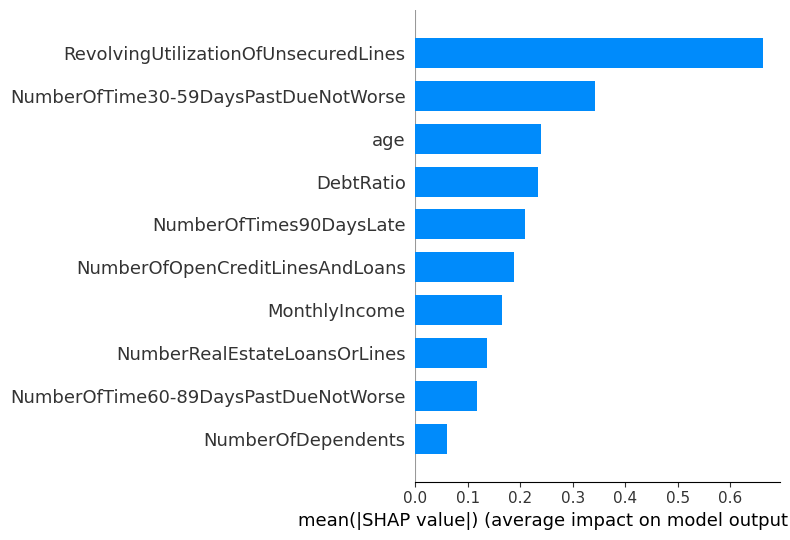

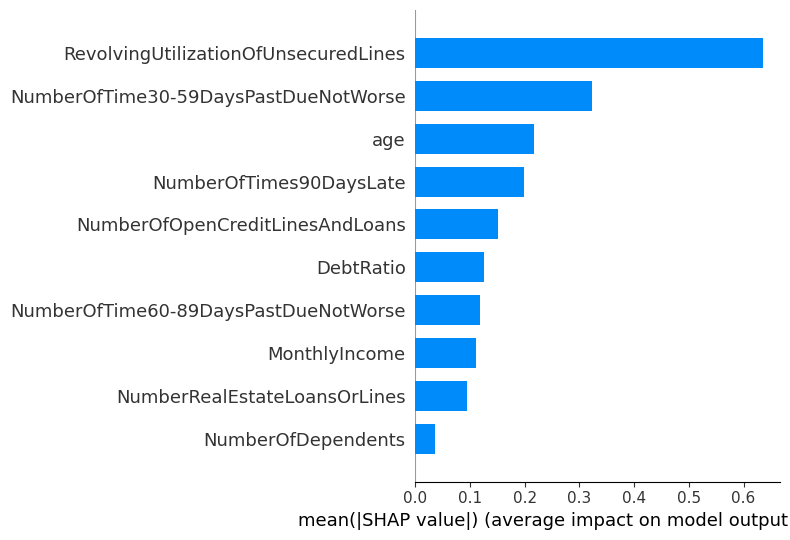

 99%|===================| 1988/2000 [01:35<00:00]        

ExplainerError: Additivity check failed in TreeExplainer! Please ensure the data matrix you passed to the explainer is the same shape that the model was trained on. If your data shape is correct then please report this on GitHub. This check failed because for one of the samples the sum of the SHAP values was 0.910300, while the model output was 0.930000. If this difference is acceptable you can set check_additivity=False to disable this check.

In [49]:
import shap
import matplotlib.pyplot as plt

# Submuestreo para interpretabilidad (evita carga innecesaria)
X_shap_sample = X_train.sample(1000, random_state=42)

# Aplicar SHAP sobre XGBoost
explainer_xgb = shap.Explainer(xgb_model, X_shap_sample)
shap_values_xgb = explainer_xgb(X_shap_sample)
shap.summary_plot(shap_values_xgb, X_shap_sample, plot_type='bar', show=True)

# Aplicar SHAP sobre LightGBM
explainer_lgb = shap.Explainer(lgb_model, X_shap_sample)
shap_values_lgb = explainer_lgb(X_shap_sample, check_additivity=False)
shap.summary_plot(shap_values_lgb, X_shap_sample, plot_type='bar', show=True)


rf_model = models["Random Forest"]

# Aplicar SHAP sobre Random Forest
explainer_rf = shap.Explainer(rf_model, X_shap_sample)
shap_values_rf = explainer_rf(X_shap_sample)
shap.summary_plot(shap_values_rf, X_shap_sample, plot_type='bar', show=True)


<Figure size 640x480 with 0 Axes>

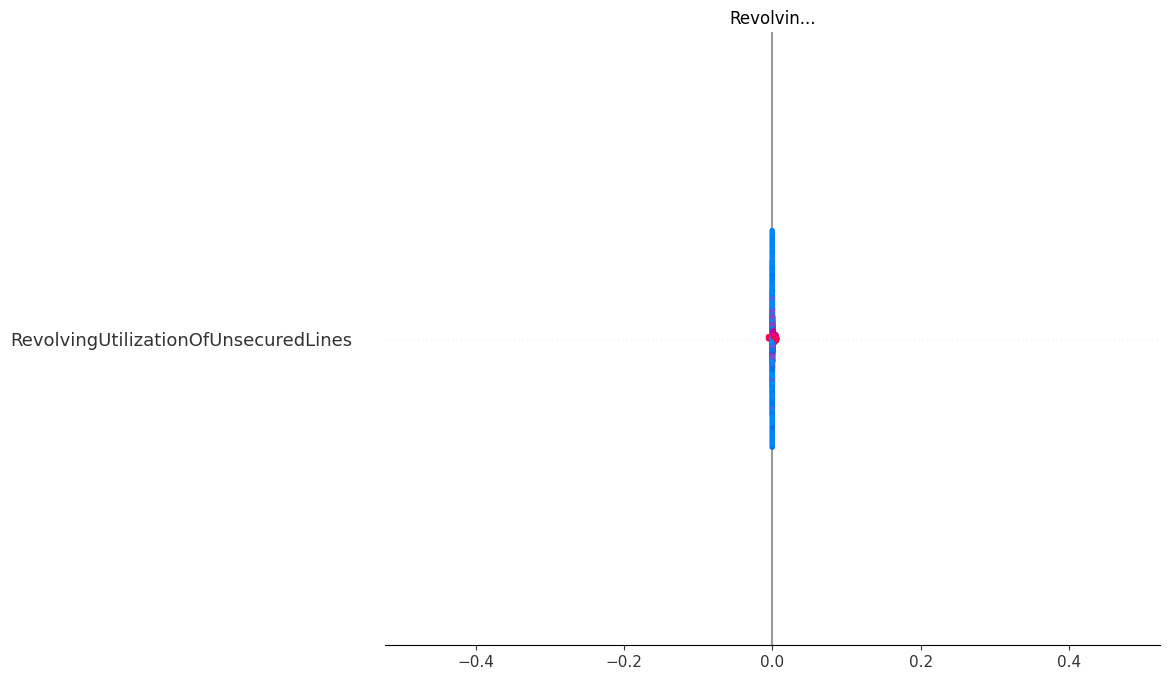

In [50]:
import shap
import torch

# Convertir a tensores y mover a GPU (si está disponible)
X_sample_np = X_train.sample(500, random_state=42).values.astype(np.float32)  # tamaño pequeño por coste
X_sample_torch = torch.tensor(X_sample_np, device=device)

# Crear background (para referencia en SHAP)
background_np = X_train.sample(100, random_state=0).values.astype(np.float32)
background_torch = torch.tensor(background_np, device=device)

# Definir función de predicción compatible
def model_nn_forward(x):
    with torch.no_grad():
        return model_nn(x).cpu().numpy()

# Usar DeepExplainer
explainer_nn = shap.DeepExplainer(model_nn, background_torch)
shap_values_nn = explainer_nn.shap_values(X_sample_torch)

# Visualización de la importancia de características
#shap.summary_plot(shap_values_nn[0], X_sample_np, feature_names=X_train.columns.tolist(), plot_type='bar')
shap.summary_plot(shap_values_nn, X_sample_np, feature_names=X_train.columns.tolist(), plot_type='bar')

